# Sleep-onset SPI-SPI embedding — EPCTL01

168 epochs of EEG (5 s @ 100 Hz, M channels: 83 full montage / 38 coarse-grained),
one SPI-SPI **pearson** feature vector per epoch from `src.process_features`.
Epoch index = time: each M×T MTS is one chunk of the continuous recording.

Stage labels (`Wake`/`N1`/`N2`) come from `manifest.csv`, joined on the
`instance` index. They are deliberately **not** written into the per-dataset
`meta.json`: `manifest.csv` + `dataset_meta.json` are the single source of truth,
and `meta.mts_class` must stay the dataset class that `process_features` reads.
Joining on `instance` is non-destructive and avoids editing 168 files.

The hypnogram is **fragmented** — Wake/N1/N2 alternate; N2 also occurs at epochs
72–83 and 120–125 before the sustained-N2 onset recorded in `dataset_meta.json`.

Stage labels are **30 s-quantized** — a clinical hypnogram upsampled ×6, so every
6 consecutive epochs (`block_id = epoch // 6`) share one label. SPI features are
genuine per-5 s-epoch; only the labels are coarse. Any supervised / cross-validated
analysis must split by `block_id` (random epoch folds leak); the embeddings and
trajectories below are unsupervised and unaffected.

In [61]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from umap import UMAP

import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca

#### Load features + join sleep-stage labels

In [62]:
# --- tensor selection: "m83" (full montage) or "m38" (coarse-grained) ---
TENSOR = "m83"
CLASS_DIR = {"m83": "epctl01-m83", "m38": "epctl01"}[TENSOR]

data = np.load(f"../../features/sleep_onset_{TENSOR}_pearson.npz", allow_pickle=True)
manifest = pd.read_csv(f"../../data/sleep_onset/{CLASS_DIR}/manifest.csv")
with open(f"../../data/sleep_onset/{CLASS_DIR}/dataset_meta.json") as fh:
    ds_meta = json.load(fh)
ONSET = ds_meta["onset_epoch"]   # epoch index where sustained N2 begins

# Feature-npz rows are in lexicographic dir order (I0, I1, I10, ...). Join the
# stage labels on the instance index, then sort to epoch (time) order. `epoch`
# is the original recording index; `instance` is the compacted dataset index
# (they differ when prep ran with --scored-only).
meta_df = pd.DataFrame({
    "instance": data["instance"].astype(int),
    "M": data["M"].astype(int),
    "T": data["T"].astype(int),
    "dataset_paths": data["dataset_paths"].astype(str),
})
meta_df = meta_df.merge(manifest, on="instance", how="left", validate="one_to_one")
order = np.argsort(meta_df["epoch"].to_numpy())
meta_df = meta_df.iloc[order].reset_index(drop=True)
X = data["X"][order]
epoch = meta_df["epoch"].to_numpy()

# Stage labels are 30 s-quantized (a clinical hypnogram upsampled x6): every 6
# consecutive epochs share one label. block_id is the grouping unit for any
# supervised / cross-validated analysis — random 5 s-epoch folds would leak.
meta_df["block_id"] = epoch // 6

# Stage as an ordered categorical (Wake -> N1 -> N2 = light -> deep sleep).
STAGES = ["Wake", "N1", "N2"]
STAGE_COLORS = {"Wake": "#e8b400", "N1": "#3a86c8", "N2": "#11205a"}
meta_df["mts_class"] = pd.Categorical(meta_df["stage"], categories=STAGES, ordered=True)
sns.set_palette([STAGE_COLORS[s] for s in STAGES])

assert meta_df["stage"].notna().all(), "unmatched epochs in manifest join"
print(f"X: {X.shape}  tensor={TENSOR}  M={meta_df['M'].iat[0]}  onset_epoch={ONSET}")
print(f"{meta_df['block_id'].nunique()} label blocks (30 s) over {len(meta_df)} epochs (5 s)")
print(meta_df["stage"].value_counts().reindex(STAGES).to_string())

X: (168, 35761)  tensor=m83  M=83  onset_epoch=144
28 label blocks (30 s) over 168 epochs (5 s)
stage
Wake     24
N1      102
N2       42


##### Feature matrix (epoch-ordered)

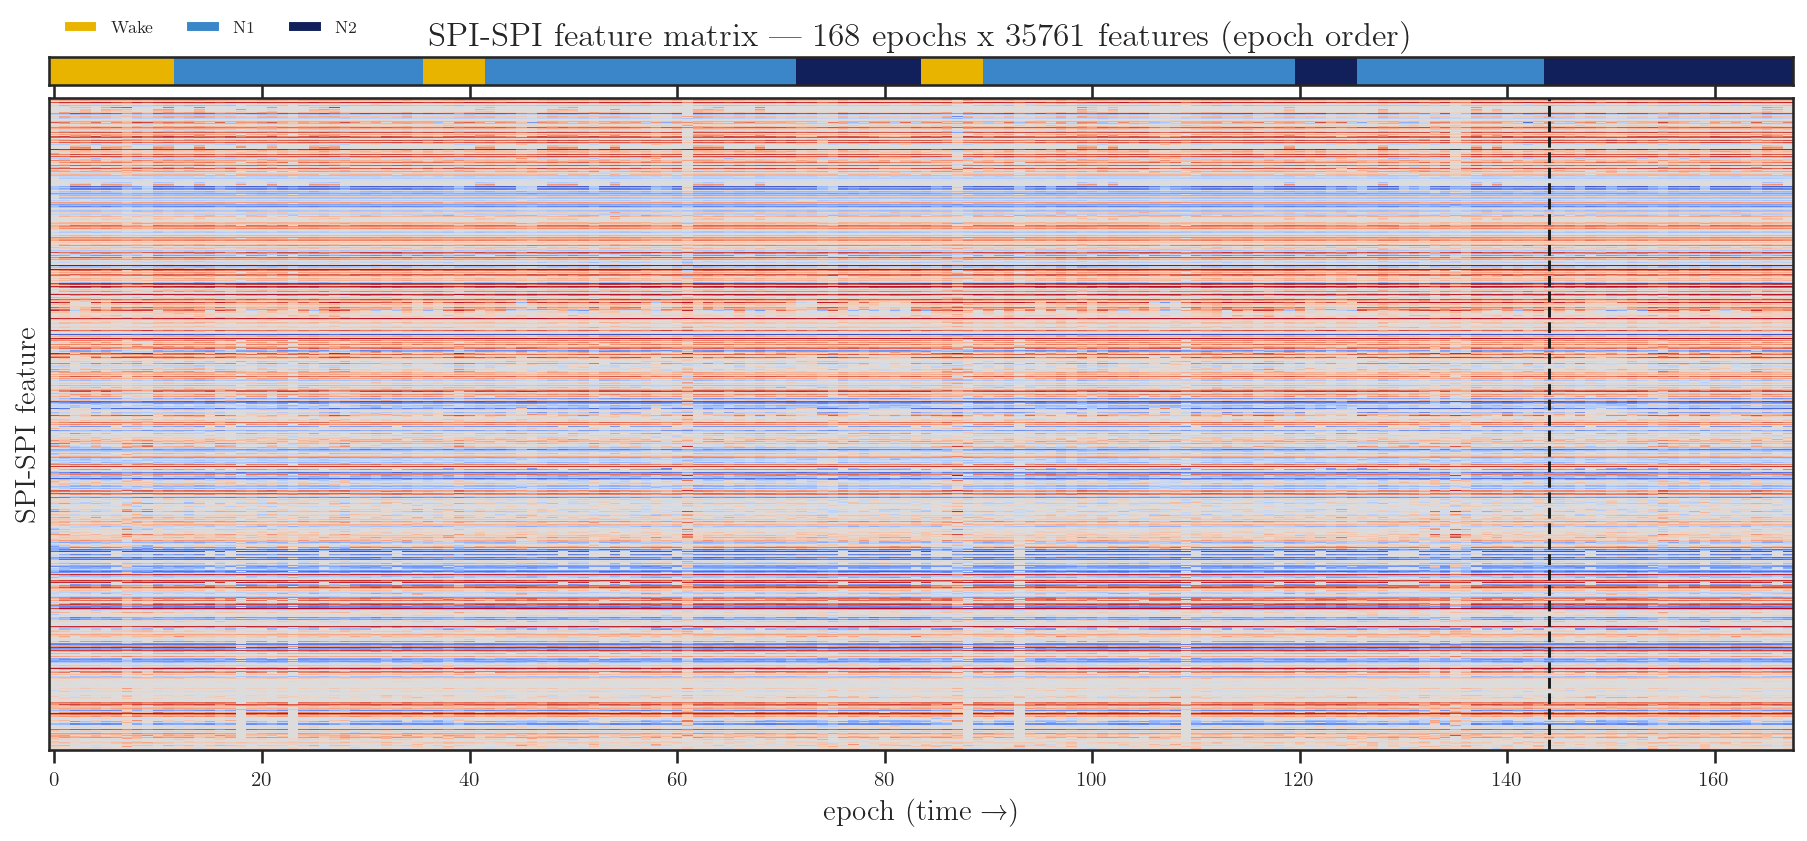

In [63]:
fig, (axc, ax) = plt.subplots(
    2, 1, figsize=(15, 6), dpi=150, sharex=True,
    gridspec_kw={"height_ratios": [1, 24], "hspace": 0.04},
)
# stage colour strip along the epoch axis
codes = meta_df["mts_class"].cat.codes.to_numpy()[None, :]
axc.imshow(codes, aspect="auto", interpolation="none", vmin=0, vmax=len(STAGES) - 1,
           cmap=ListedColormap([STAGE_COLORS[s] for s in STAGES]),
           extent=[epoch[0] - 0.5, epoch[-1] + 0.5, 0, 1])
axc.set_yticks([])
axc.set_title(f"SPI-SPI feature matrix — {X.shape[0]} epochs x {X.shape[1]} features (epoch order)")
axc.legend(handles=[Patch(facecolor=STAGE_COLORS[s], label=s) for s in STAGES],
           loc="lower left", bbox_to_anchor=(0, 1.25), ncol=3, fontsize=8, frameon=False)

ax.imshow(X.T, aspect="auto", cmap="coolwarm", vmin=-1, vmax=1, interpolation="none",
          extent=[epoch[0] - 0.5, epoch[-1] + 0.5, X.shape[1], 0])
ax.axvline(ONSET, color="k", lw=1.4, ls="--")
ax.set_xlabel("epoch (time →)")
ax.set_ylabel("SPI-SPI feature")
ax.set_yticks([])
plt.show()

##### PCA — 2D

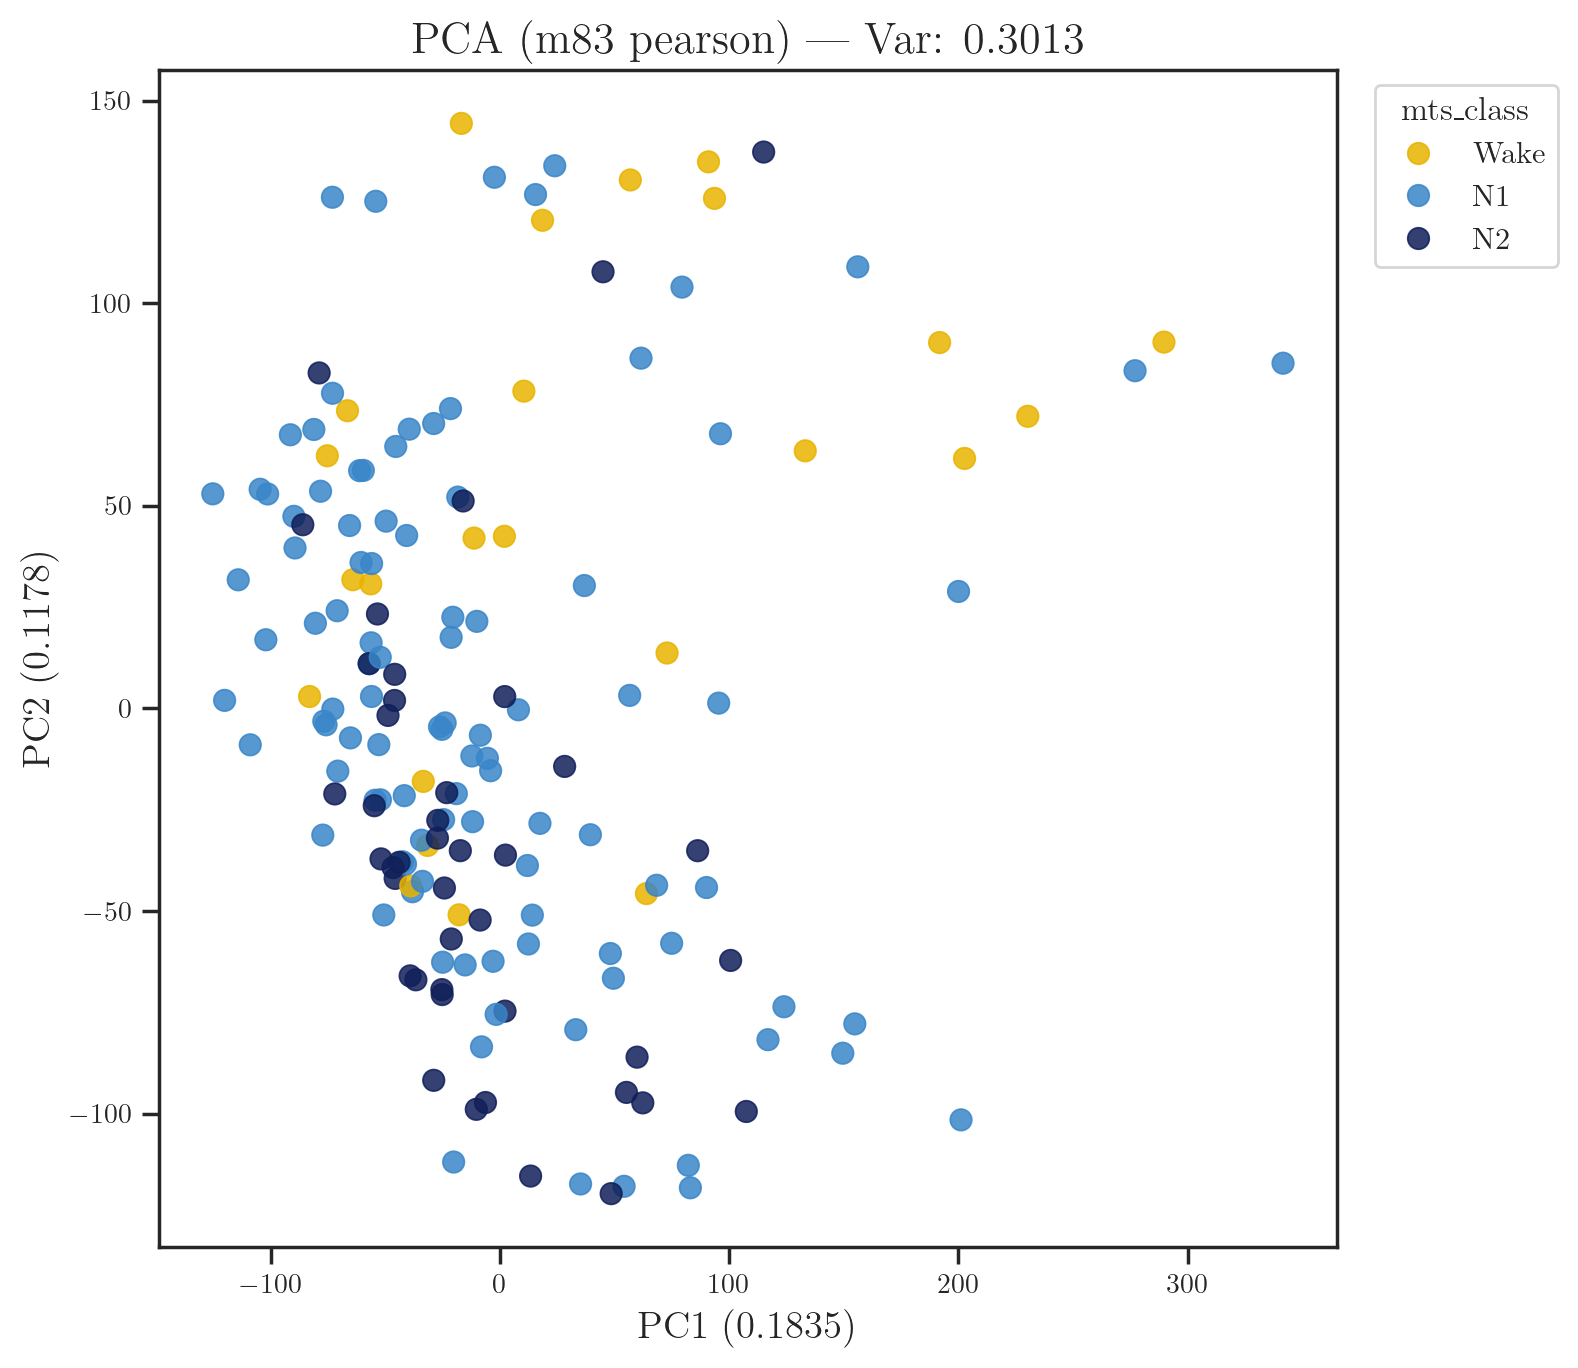

In [64]:
fig, ax = plt.subplots(figsize=(9, 7), dpi=200)
emb_pca2, _ = plot_pca(X, meta_df, size_col=None, s=60, alpha=0.85, ax=ax,
                       feature_space=f"{TENSOR} pearson")
plt.tight_layout()
plt.show()

##### PCA — 3D (interactive)

In [65]:
X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=3, random_state=0)
emb3 = pca.fit_transform(X_scaled)
var3 = pca.explained_variance_ratio_

df3 = meta_df.assign(PC1=emb3[:, 0], PC2=emb3[:, 1], PC3=emb3[:, 2])
fig = px.scatter_3d(
    df3, x="PC1", y="PC2", z="PC3",
    color="stage", color_discrete_map=STAGE_COLORS, category_orders={"stage": STAGES},
    hover_data={"instance": True, "stage": True, "PC1": ":.2f", "PC2": ":.2f", "PC3": ":.2f"},
    title=f"PCA 3D | var {var3.sum():.3f}  (PC1 {var3[0]:.3f}, PC2 {var3[1]:.3f}, PC3 {var3[2]:.3f})",
    width=950, height=720,
)
fig.update_traces(marker=dict(size=5, opacity=0.85))
fig.update_layout(scene=dict(aspectmode="cube"))
fig.show()

##### UMAP — 2D

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


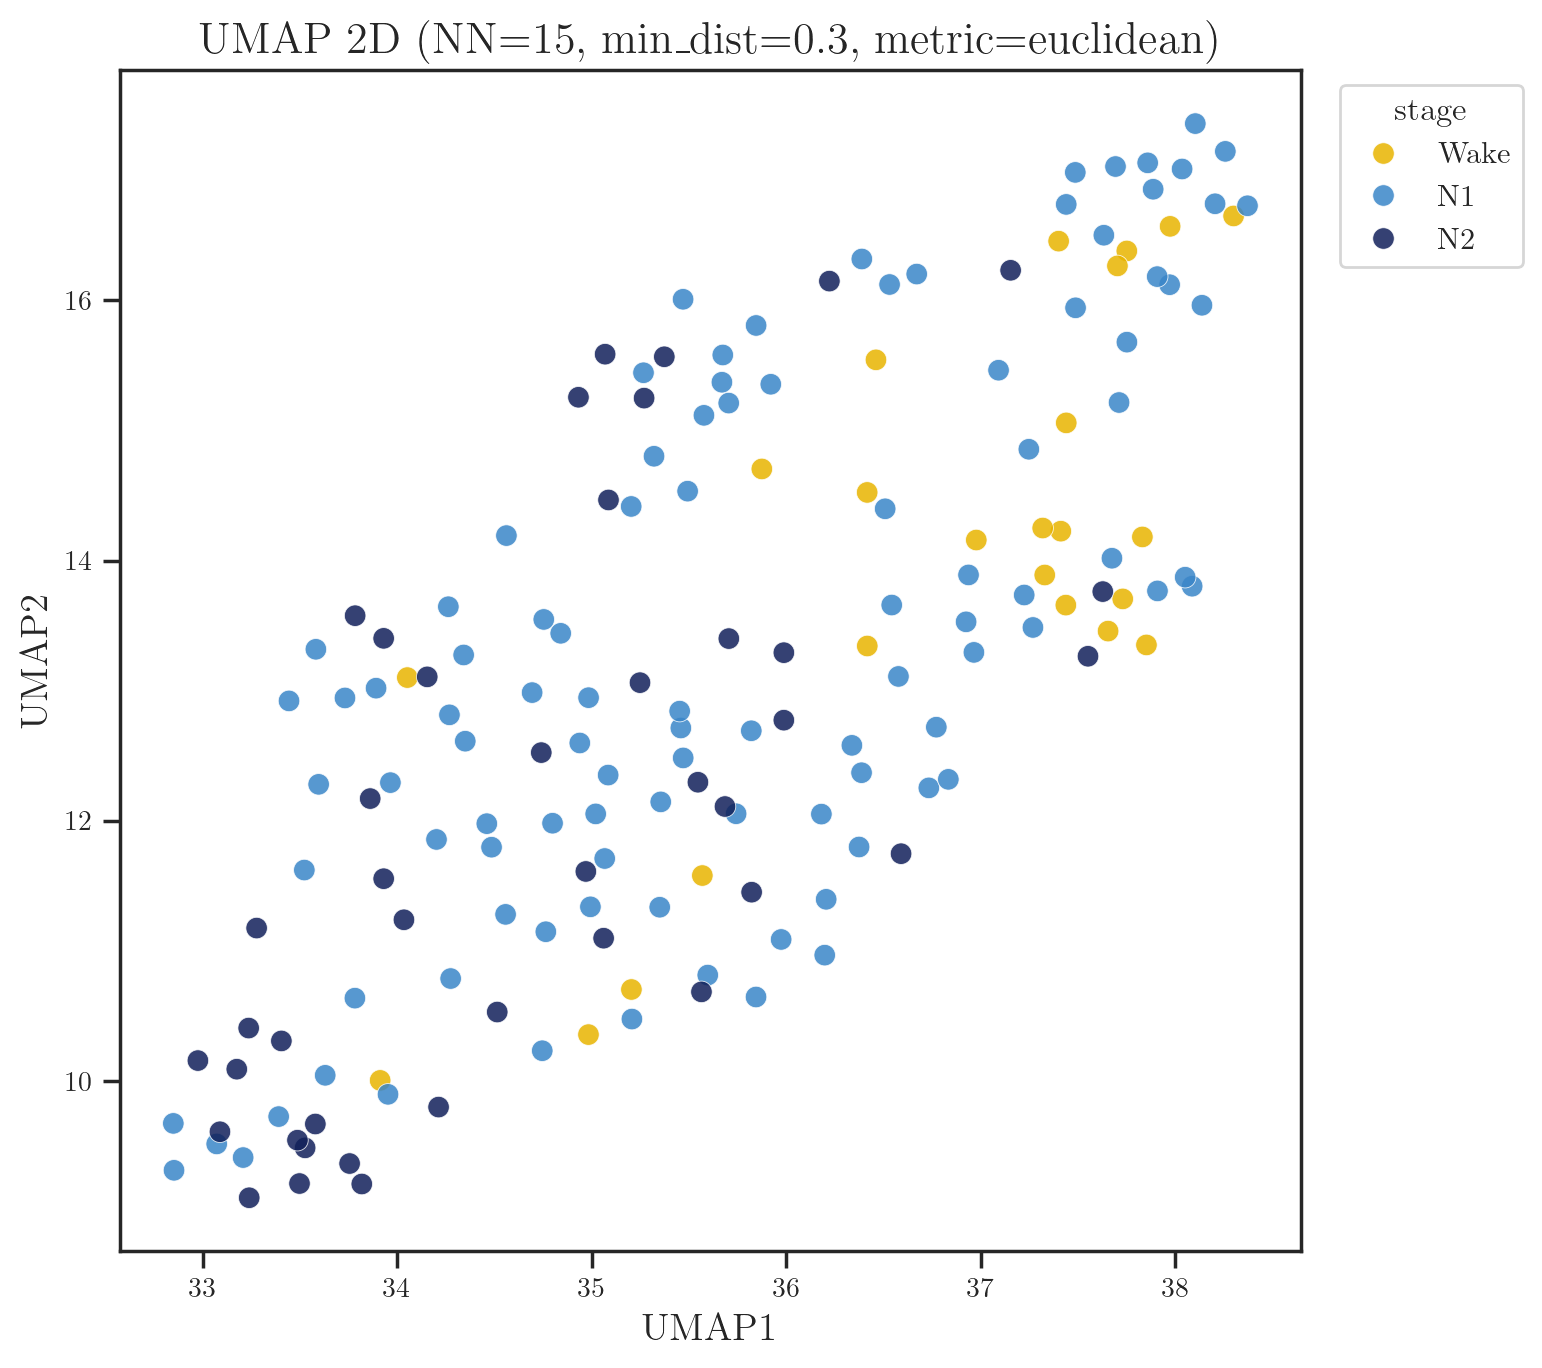

In [66]:
# UMAP hyperparameters — tune NN / min_dist / metric for cluster separation.
UMAP_NN = 15
UMAP_MIN_DIST = 0.3
UMAP_METRIC = "euclidean"

emb_u2 = UMAP(n_components=2, n_neighbors=UMAP_NN, min_dist=UMAP_MIN_DIST,
              metric=UMAP_METRIC, random_state=0).fit_transform(X)
df_u = meta_df.assign(UMAP1=emb_u2[:, 0], UMAP2=emb_u2[:, 1])

fig, ax = plt.subplots(figsize=(8, 7), dpi=200)
sns.scatterplot(data=df_u, x="UMAP1", y="UMAP2", hue="mts_class",
                palette=STAGE_COLORS, s=60, alpha=0.85, edgecolor="white",
                linewidth=0.3, ax=ax)
ax.set_title(f"UMAP 2D (NN={UMAP_NN}, min_dist={UMAP_MIN_DIST}, metric={UMAP_METRIC})")
ax.set_box_aspect(1)
ax.legend(title="stage", loc="upper left", bbox_to_anchor=(1.02, 1), frameon=True)
plt.tight_layout()
plt.show()

##### UMAP — 3D (interactive)

In [67]:
emb_u3 = UMAP(n_components=3, n_neighbors=UMAP_NN, min_dist=UMAP_MIN_DIST,
              metric=UMAP_METRIC, random_state=0).fit_transform(X)
df_u3 = meta_df.assign(UMAP1=emb_u3[:, 0], UMAP2=emb_u3[:, 1], UMAP3=emb_u3[:, 2])
fig = px.scatter_3d(
    df_u3, x="UMAP1", y="UMAP2", z="UMAP3",
    color="stage", color_discrete_map=STAGE_COLORS, category_orders={"stage": STAGES},
    hover_data={"instance": True, "stage": True},
    title=f"UMAP 3D (NN={UMAP_NN}, min_dist={UMAP_MIN_DIST}, metric={UMAP_METRIC})",
    width=950, height=720,
)
fig.update_traces(marker=dict(size=5, opacity=0.85))
fig.update_layout(scene=dict(aspectmode="cube"))
fig.show()

/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


#### Trajectory: distance (time) to sleep onset

Epoch index is time (one 5 s step per epoch). Below, the embedding is coloured
by epoch and consecutive epochs are joined — the path from Wake into sustained
N2. A centred **moving average** on each component smooths the path.

PCA drives the trajectory: components are linear, variance-ordered and stable,
so a per-component *time series* is meaningful. UMAP axes are neither ordered
nor metric — kept above for cluster views, not used as a 1-D series.

The fragmented hypnogram (N2 excursions at epochs 72–83 and 120–125) means the
trajectory will show those returns toward deep sleep, not one monotone descent.

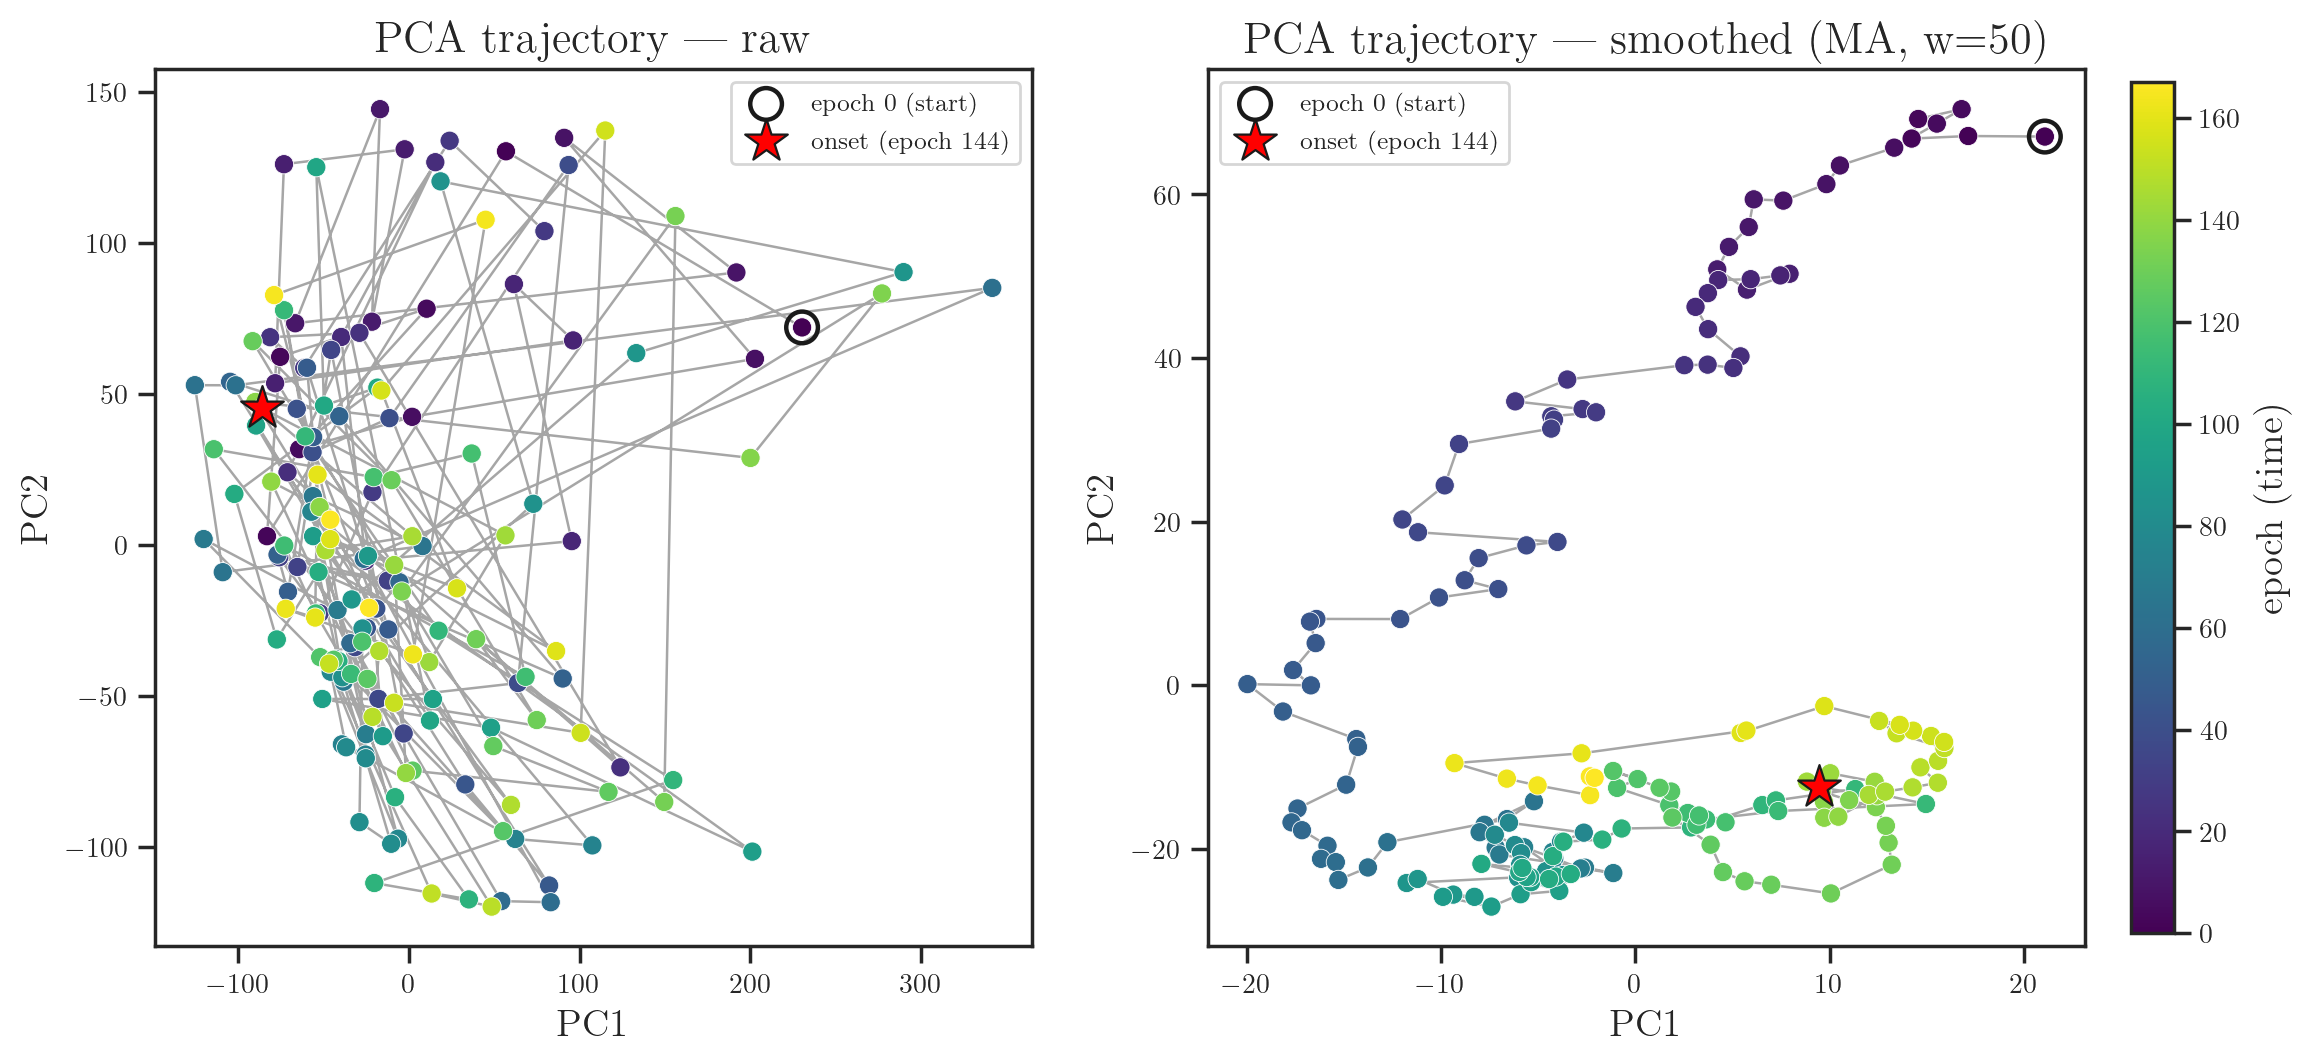

In [83]:
def smooth(a, w):
    # centred moving average along the epoch axis (axis 0); edges shrink the window
    return pd.DataFrame(np.asarray(a, float)).rolling(w, center=True, min_periods=1).mean().to_numpy()

def shade_stages(ax):
    # shade the epoch-axis background by sleep stage
    st = meta_df["stage"].to_numpy()
    s = 0
    for i in range(1, len(st) + 1):
        if i == len(st) or st[i] != st[s]:
            ax.axvspan(epoch[s] - 0.5, epoch[i - 1] + 0.5,
                       color=STAGE_COLORS[st[s]], alpha=0.15, zorder=0)
            s = i

SMOOTH_W = 50   # moving-average window (epochs); 7 epochs = 35 s
onset_idx = int(np.where(epoch == ONSET)[0][0])

emb2 = emb3[:, :2]
emb2_s = smooth(emb2, SMOOTH_W)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=200)
for ax, E, ttl in [(axes[0], emb2, "raw"), (axes[1], emb2_s, f"smoothed (MA, w={SMOOTH_W})")]:
    ax.plot(E[:, 0], E[:, 1], "-", color="0.65", lw=0.9, zorder=1)
    sc = ax.scatter(E[:, 0], E[:, 1], c=epoch, cmap="viridis", s=48,
                    edgecolor="white", linewidth=0.3, zorder=2)
    ax.scatter(*E[0], s=130, marker="o", facecolor="none", edgecolor="k",
               lw=1.6, zorder=3, label="epoch 0 (start)")
    ax.scatter(*E[onset_idx], s=260, marker="*", facecolor="red", edgecolor="k",
               lw=0.8, zorder=3, label=f"onset (epoch {ONSET})")
    ax.set_title(f"PCA trajectory — {ttl}")
    ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
    ax.set_box_aspect(1); ax.legend(loc="best", fontsize=9)
fig.colorbar(sc, ax=axes, label="epoch (time)", shrink=0.85, pad=0.02)
plt.show()

##### Component time series (1-D trajectories) + moving-average smoothing

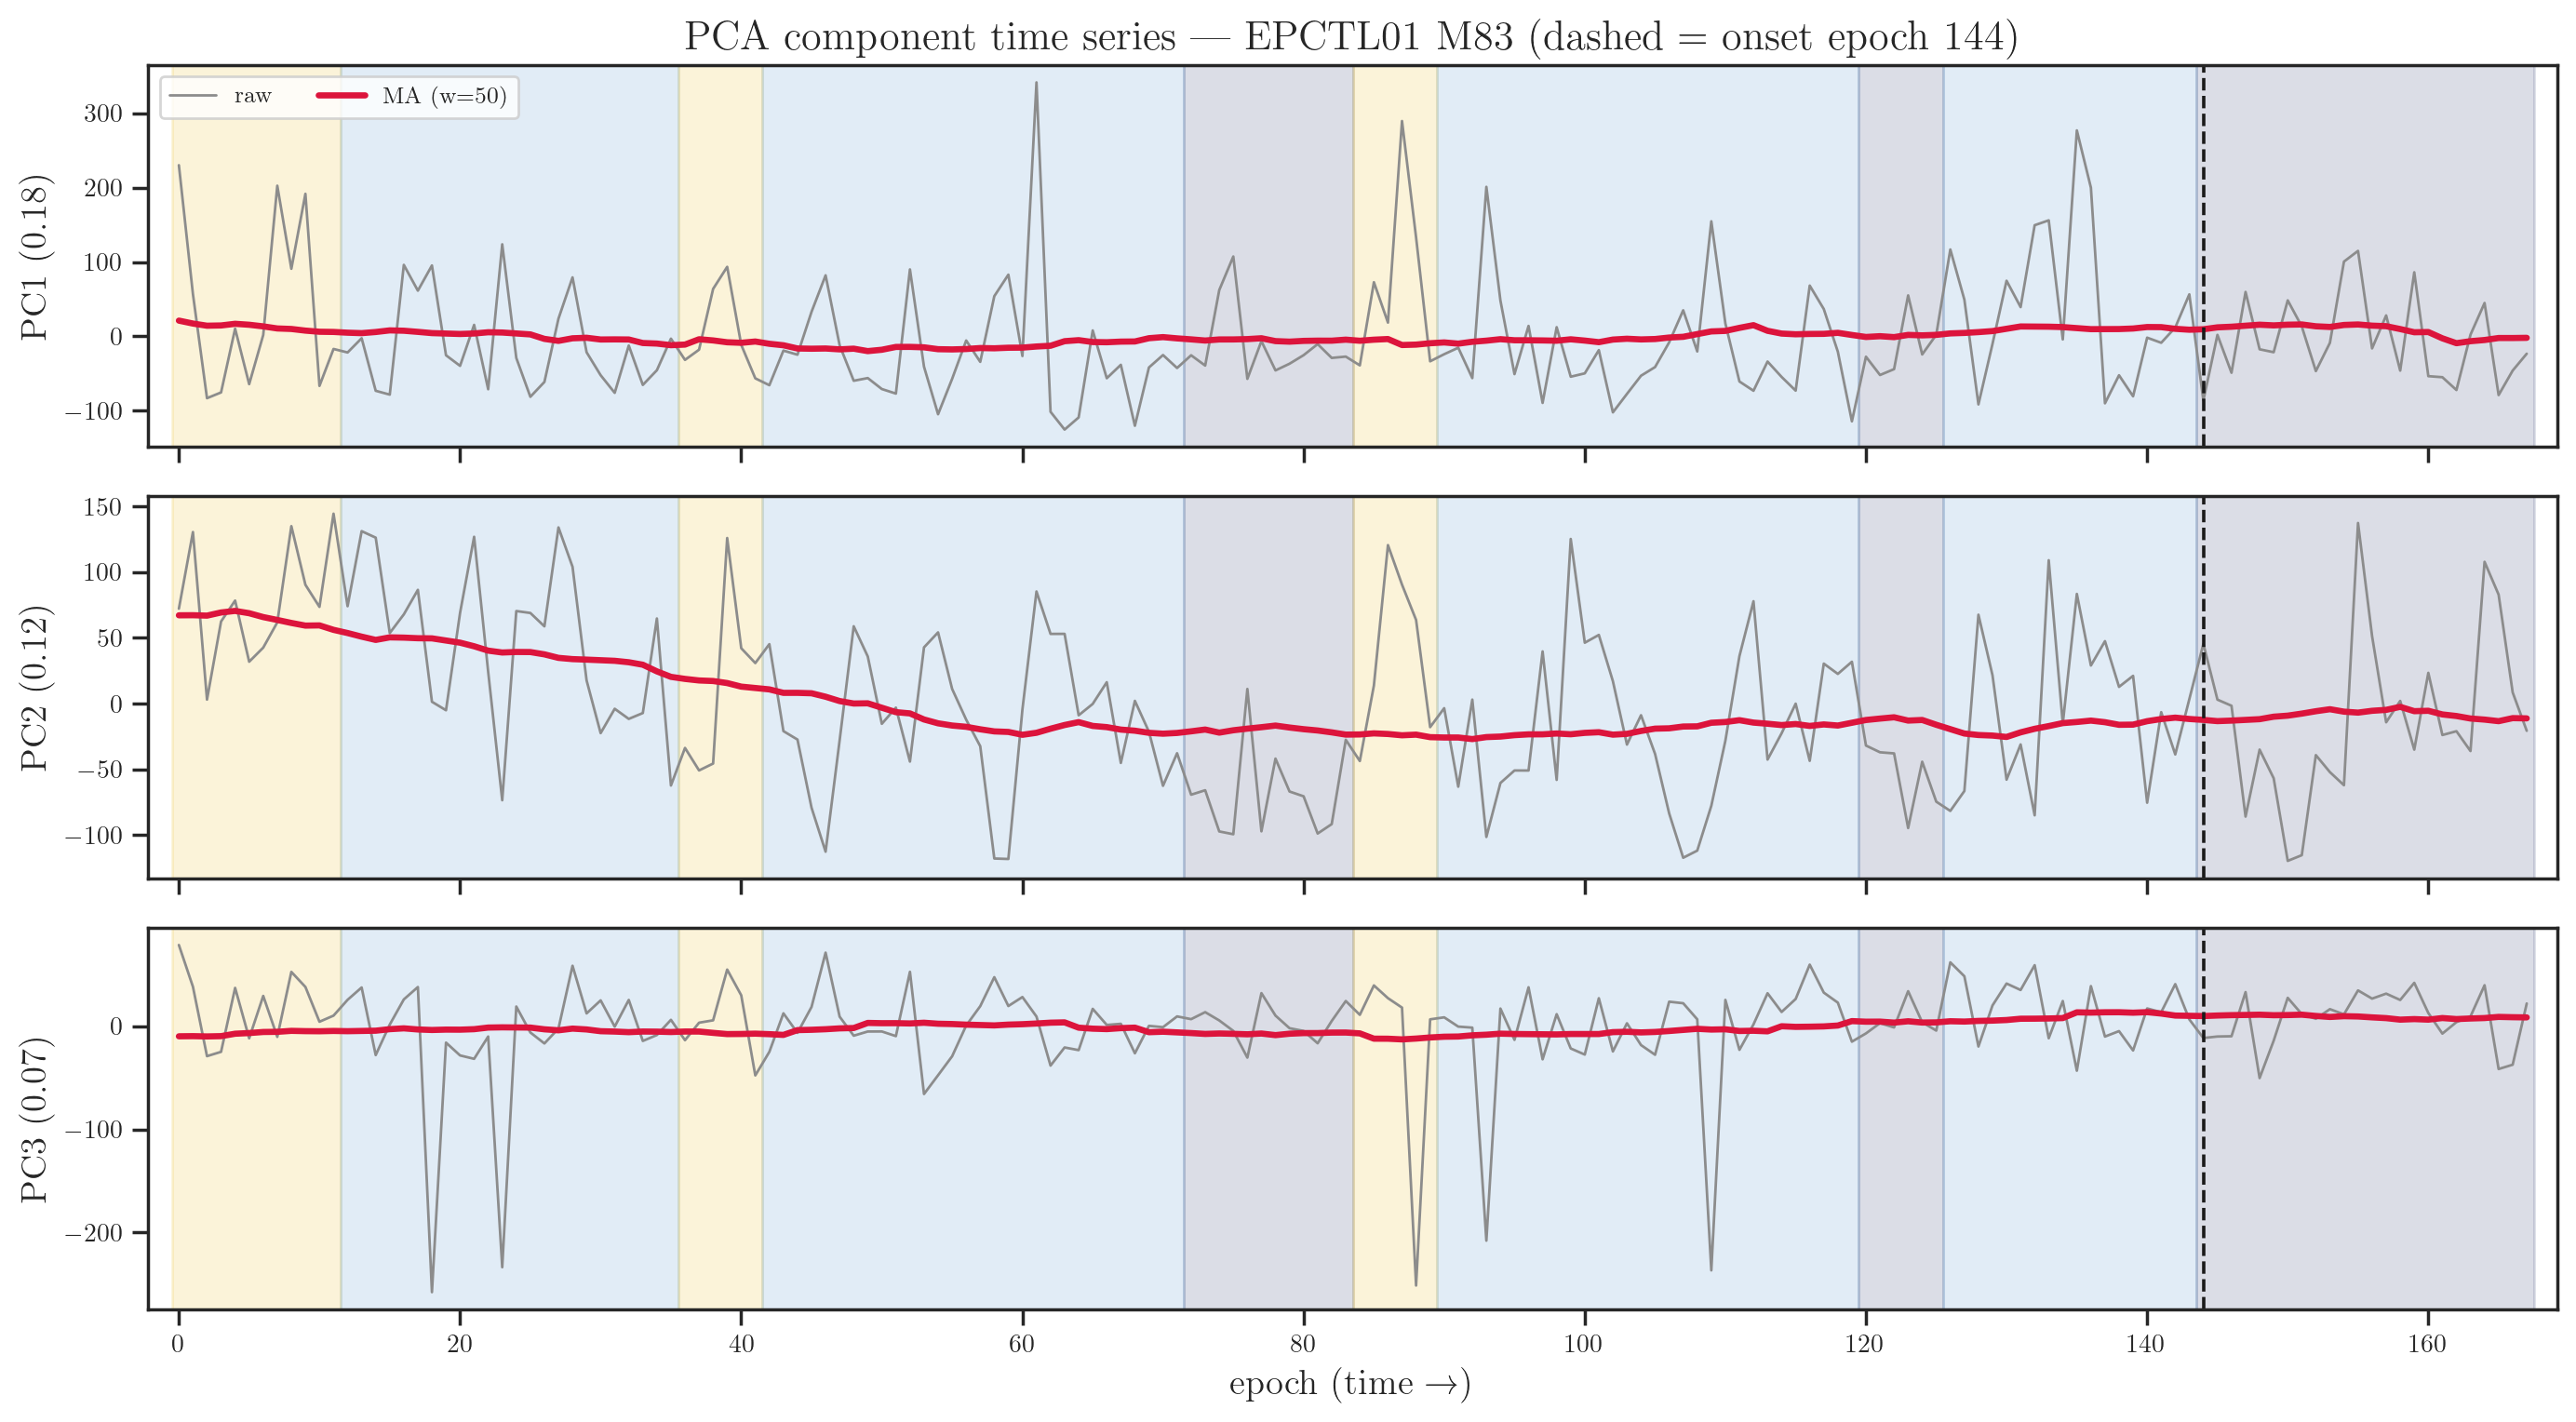

Spearman rho of each PC with epoch index (descriptive):
  PC1: rho=+0.047
  PC2: rho=-0.314
  PC3: rho=+0.084


In [84]:
N_COMP = 3
pcs = emb3[:, :N_COMP]
pcs_s = smooth(pcs, SMOOTH_W)

axs = np.atleast_1d(plt.subplots(N_COMP, 1, figsize=(14, 2.6 * N_COMP),
                                 dpi=200, sharex=True)[1])
for k, ax in enumerate(axs):
    shade_stages(ax)
    ax.plot(epoch, pcs[:, k], color="0.55", lw=1.0, label="raw")
    ax.plot(epoch, pcs_s[:, k], color="crimson", lw=2.4, label=f"MA (w={SMOOTH_W})")
    ax.axvline(ONSET, color="k", ls="--", lw=1.3)
    ax.set_ylabel(f"PC{k + 1}  ({var3[k]:.2f})")
    ax.margins(x=0.01)
    if k == 0:
        ax.legend(loc="upper left", ncol=2, fontsize=9)
axs[-1].set_xlabel("epoch (time →)")
axs[0].set_title(f"PCA component time series — EPCTL01 {TENSOR.upper()}  "
                 f"(dashed = onset epoch {ONSET})")
plt.tight_layout()
plt.show()

# Spearman rho with epoch index — DESCRIPTIVE ONLY. The naive p-value is invalid
# here (epochs are autocorrelated and labels are 30 s-quantized, so the epochs
# are not independent) and is omitted; proper inference needs a block-grouped
# held-out test.
print("Spearman rho of each PC with epoch index (descriptive):")
for k in range(N_COMP):
    rho, _ = spearmanr(epoch, pcs[:, k])
    print(f"  PC{k + 1}: rho={rho:+.3f}")

##### 3-D PCA trajectory (interactive)

In [70]:
emb3_s = smooth(emb3, SMOOTH_W)
hover = [f"epoch {e} | {s}" for e, s in zip(epoch, meta_df["stage"])]

fig = go.Figure()
fig.add_trace(go.Scatter3d(
    x=emb3[:, 0], y=emb3[:, 1], z=emb3[:, 2], mode="lines+markers", name="raw",
    line=dict(width=2, color="lightgray"),
    marker=dict(size=3, color=epoch, colorscale="Viridis",
                colorbar=dict(title="epoch"), opacity=0.7),
    text=hover, hoverinfo="text",
))
fig.add_trace(go.Scatter3d(
    x=emb3_s[:, 0], y=emb3_s[:, 1], z=emb3_s[:, 2], mode="lines+markers",
    name=f"smoothed (w={SMOOTH_W})",
    line=dict(width=6, color=epoch, colorscale="Viridis"),
    marker=dict(size=2, color=epoch, colorscale="Viridis"),
    text=hover, hoverinfo="text",
))
for idx, label, col in [(0, "epoch 0", "black"), (onset_idx, f"onset {ONSET}", "red")]:
    fig.add_trace(go.Scatter3d(
        x=[emb3[idx, 0]], y=[emb3[idx, 1]], z=[emb3[idx, 2]], mode="markers",
        name=label, marker=dict(size=7, color=col, symbol="diamond"),
    ))
fig.update_layout(
    title=f"PCA 3D trajectory — EPCTL01 {TENSOR.upper()}",
    width=950, height=720,
    scene=dict(xaxis_title="PC1", yaxis_title="PC2", zaxis_title="PC3", aspectmode="cube"),
)
fig.show()